# DataModule & Dataset tests
Checks correctness and visualises a single batch from train/val/test splits.

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from fm4tag.datasets.datasets import DatasetCatCon, cat_con_collate_fn
from fm4tag.datamodules.datamodule import CatConDataModule

In [3]:
cfg = OmegaConf.load('../configs/default.yaml')

TRAIN_PATH = cfg.train_dataset_path
VAL_PATH = cfg.val_dataset_path
TEST_PATH = cfg.test_dataset_path
NORM_DICT_PATH = cfg.norm_dict_path
CLASS_DICT_PATH = cfg.class_dict_path

VARIABLES = cfg.variables
GLOBAL_OBJECT = cfg.global_object
CONSTITUENT_OBJECTS = list(cfg.constituent_objects)

print('train :', TRAIN_PATH)
print('val   :', VAL_PATH)
print('test  :', TEST_PATH)

train : /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/train/output/pp_output_train.h5
val   : /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/val/output/pp_output_val.h5
test  : /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/test/output/pp_output_test.h5



---
## 1  DatasetCatCon — single sample

In [4]:
import yaml

with open(NORM_DICT_PATH) as f:
    norm_dict = yaml.safe_load(f)
with open(CLASS_DICT_PATH) as f:
    class_dict = yaml.safe_load(f)

ds = DatasetCatCon(
    file_path=VAL_PATH,
    variables=VARIABLES,
    global_object=GLOBAL_OBJECT,
    constituent_objects=CONSTITUENT_OBJECTS,
    norm_dict=norm_dict,
    class_dict=class_dict,
)
print(f'\nDataset length : {len(ds):,}')


DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/val/output/pp_output_val.h5
  samples : 1860000

Dataset length : 1,860,000


In [5]:
sample = ds[0]

print('── sample keys ──────────────────────────────')
print('label       :', sample['label'], '  dtype:', sample['label'].dtype)
print('global shape:', sample['global'].shape, '  dtype:', sample['global'].dtype)

for obj, d in sample['constituents'].items():
    print(f'\nconstituents[{obj}]')
    for k, v in d.items():
        print(f'  {k:12s}: shape={tuple(v.shape)}  dtype={v.dtype}')

── sample keys ──────────────────────────────
label       : tensor(0)   dtype: torch.int64
global shape: torch.Size([2])   dtype: torch.float32

constituents[tracks]
  categorical : shape=(40, 9)  dtype=torch.uint8
  continuous  : shape=(40, 10)  dtype=torch.float32
  valid       : shape=(40,)  dtype=torch.bool


In [6]:
# Expected dtypes
assert sample['label'].dtype == torch.long, f'label dtype: {sample["label"].dtype}'
assert sample['global'].dtype == torch.float32, (
    f'global dtype: {sample["global"].dtype}'
)
for obj, d in sample['constituents'].items():
    assert (
        d['categorical'].dtype == torch.int64
        or d['categorical'].dtype.is_floating_point == False
    )
    assert d['continuous'].dtype == torch.float32, (
        f'{obj} continuous dtype: {d["continuous"].dtype}'
    )
    assert d['valid'].dtype == torch.bool, f'{obj} valid dtype: {d["valid"].dtype}'
print('dtype assertions passed')

dtype assertions passed


In [7]:
# Expected feature dimensions from config
n_global_feats = len(VARIABLES[GLOBAL_OBJECT].inputs)
assert sample['global'].shape == (n_global_feats,), (
    f'global shape {sample["global"].shape} != ({n_global_feats},)'
)
for obj in CONSTITUENT_OBJECTS:
    n_cat = len(VARIABLES[obj].inputs.categorical)
    n_con = len(VARIABLES[obj].inputs.continuous)
    N = sample['constituents'][obj]['categorical'].shape[0]
    assert sample['constituents'][obj]['categorical'].shape == (N, n_cat), (
        'cat shape mismatch'
    )
    assert sample['constituents'][obj]['continuous'].shape == (N, n_con), (
        'con shape mismatch'
    )
    assert sample['constituents'][obj]['valid'].shape == (N,), 'valid shape mismatch'
print('shape assertions passed')

shape assertions passed


---
## 2  cat_con_collate_fn — manual batch

In [8]:
BATCH_SIZE = 8
samples = [ds[i] for i in range(BATCH_SIZE)]
batch = cat_con_collate_fn(samples)

print('── collated batch ───────────────────────────')
print('label  :', batch['label'].shape, batch['label'].dtype)
print('global :', batch['global'].shape, batch['global'].dtype)
for obj, d in batch['constituents'].items():
    print(f'\nconstituents[{obj}]')
    for k, v in d.items():
        print(f'  {k:12s}: {tuple(v.shape)}  {v.dtype}')

── collated batch ───────────────────────────
label  : torch.Size([8]) torch.int64
global : torch.Size([8, 2]) torch.float32

constituents[tracks]
  categorical : (8, 40, 9)  torch.int64
  continuous  : (8, 40, 10)  torch.float32
  valid       : (8, 40)  torch.bool


In [9]:
assert batch['label'].shape == (BATCH_SIZE,)
assert batch['global'].shape[0] == BATCH_SIZE
for obj, d in batch['constituents'].items():
    assert d['categorical'].shape[0] == BATCH_SIZE
    assert d['continuous'].shape[0] == BATCH_SIZE
    assert d['valid'].shape[0] == BATCH_SIZE
print('collate shape assertions passed')

collate shape assertions passed


---
## 3  CatConDataModule — setup + one batch per split

In [10]:
dm = CatConDataModule(
    train_dataset_path=TRAIN_PATH,
    val_dataset_path=VAL_PATH,
    test_dataset_path=TEST_PATH,
    variables=VARIABLES,
    global_object=GLOBAL_OBJECT,
    constituent_objects=CONSTITUENT_OBJECTS,
    norm_dict_path=NORM_DICT_PATH,
    class_dict_path=CLASS_DICT_PATH,
    batch_size=512,
    num_workers=2,
    pin_memory=False,  # not needed in a notebook
)
dm.setup('fit')
dm.setup('test')
print('setup done')
print(f'  train : {len(dm._train_dataset):,} samples')
print(f'  val   : {len(dm._val_dataset):,} samples')
print(f'  test  : {len(dm._test_dataset):,} samples')


DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/train/output/pp_output_train.h5
  samples : 18600000

DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/val/output/pp_output_val.h5
  samples : 1860000

DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/test/output/pp_output_test.h5
  samples : 1860000
setup done
  train : 18,600,000 samples
  val   : 1,860,000 samples
  test  : 1,860,000 samples


In [11]:
def inspect_batch(name, loader):
    batch = next(iter(loader))
    print(f'\n── {name} ─────────────────────────────────')
    print(f'  label    {tuple(batch["label"].shape)}  {batch["label"].dtype}')
    print(f'  global   {tuple(batch["global"].shape)}  {batch["global"].dtype}')
    for obj, d in batch['constituents'].items():
        n_valid = d['valid'].sum().item()
        total = d['valid'].numel()
        print(
            f'  {obj}: cat={tuple(d["categorical"].shape)}  con={tuple(d["continuous"].shape)}  '
            f'valid={n_valid}/{total} ({100 * n_valid / total:.1f}%)'
        )
    return batch


train_batch = inspect_batch('train_dataloader', dm.train_dataloader())
val_batch = inspect_batch('val_dataloader', dm.val_dataloader())
test_batch = inspect_batch('test_dataloader', dm.test_dataloader())
pred_batch = inspect_batch('predict_dataloader', dm.predict_dataloader())


── train_dataloader ─────────────────────────────────
  label    (512,)  torch.int64
  global   (512, 2)  torch.float32
  tracks: cat=(512, 40, 9)  con=(512, 40, 10)  valid=3669/20480 (17.9%)

── val_dataloader ─────────────────────────────────
  label    (512,)  torch.int64
  global   (512, 2)  torch.float32
  tracks: cat=(512, 40, 9)  con=(512, 40, 10)  valid=3607/20480 (17.6%)

── test_dataloader ─────────────────────────────────
  label    (512,)  torch.int64
  global   (512, 2)  torch.float32
  tracks: cat=(512, 40, 9)  con=(512, 40, 10)  valid=3499/20480 (17.1%)

── predict_dataloader ─────────────────────────────────
  label    (512,)  torch.int64
  global   (512, 2)  torch.float32
  tracks: cat=(512, 40, 9)  con=(512, 40, 10)  valid=3499/20480 (17.1%)


In [19]:
dir(dm)

['CHECKPOINT_HYPER_PARAMS_KEY',
 'CHECKPOINT_HYPER_PARAMS_NAME',
 'CHECKPOINT_HYPER_PARAMS_TYPE',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__jit_unused_properties__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_batch_size',
 '_class_dict',
 '_constituent_objects',
 '_global_object',
 '_hparams',
 '_hparams_initial',
 '_hparams_name',
 '_load_yaml',
 '_log_hyperparams',
 '_make_dataloader',
 '_norm_dict',
 '_num_workers',
 '_pin_memory',
 '_prefetch_factor',
 '_set_hparams',
 '_test_dataset',
 '_test_dataset_path',
 '_to_hparams_dict',
 '_train_dataset',
 '_train_dataset_path',
 '_val_dataset',
 '_val_dataset_path',
 '_v

---
## 4  Normalisation check — continuous features should be ~N(0,1)

In [12]:
# Collect a larger sample (4 batches) for stable statistics
loader = dm.val_dataloader()
con_data = {obj: [] for obj in CONSTITUENT_OBJECTS}
global_data = []

for i, b in enumerate(loader):
    global_data.append(b['global'])
    for obj in CONSTITUENT_OBJECTS:
        mask = b['constituents'][obj]['valid']  # (B, N)
        con = b['constituents'][obj]['continuous']  # (B, N, F)
        con_data[obj].append(con[mask])  # (n_valid, F)
    if i >= 3:
        break

global_tensor = torch.cat(global_data)  # (n_jets, F_g)
print('── global features (should be ~N(0,1)) ──────')
feat_names = list(VARIABLES[GLOBAL_OBJECT].inputs)
for j, name in enumerate(feat_names):
    col = global_tensor[:, j]
    print(f'  {name:30s}  mean={col.mean():+.3f}  std={col.std():.3f}')

for obj in CONSTITUENT_OBJECTS:
    tensor = torch.cat(con_data[obj])  # (n_valid, F_con)
    print(f'\n── {obj} continuous (should be ~N(0,1)) ──')
    for j, name in enumerate(list(VARIABLES[obj].inputs.continuous)):
        col = tensor[:, j]
        print(f'  {name:45s}  mean={col.mean():+.3f}  std={col.std():.3f}')

── global features (should be ~N(0,1)) ──────
  pt_btagJes                      mean=-0.084  std=0.907
  eta_btagJes                     mean=+0.034  std=0.993

── tracks continuous (should be ~N(0,1)) ──
  d0                                             mean=-0.001  std=1.025
  z0SinTheta                                     mean=-0.011  std=1.021
  dphi                                           mean=+0.012  std=1.011
  deta                                           mean=+0.004  std=1.014
  qOverP                                         mean=-0.005  std=1.009
  lifetimeSignedD0Significance                   mean=-0.012  std=1.000
  lifetimeSignedZ0SinThetaSignificance           mean=+0.002  std=1.027
  phiUncertainty                                 mean=+0.012  std=0.774
  thetaUncertainty                               mean=+0.017  std=1.011
  qOverPUncertainty                              mean=+0.007  std=0.949


---
## 5  Label distribution

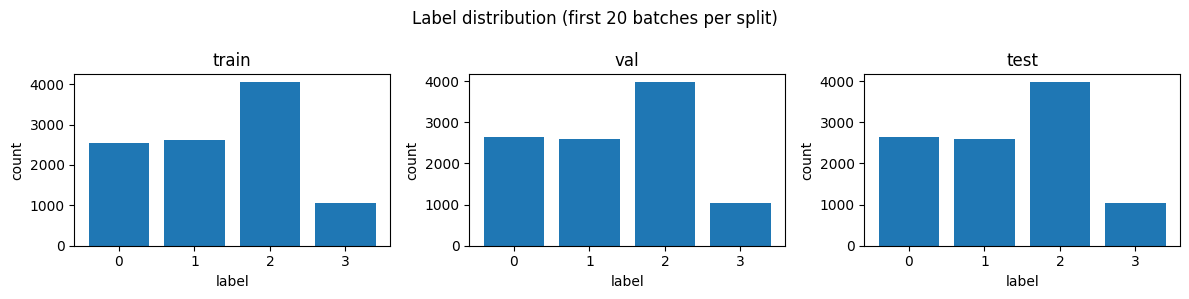

In [13]:
# Collect labels from first 20 batches of each split
def collect_labels(loader, n_batches=20):
    labels = []
    for i, b in enumerate(loader):
        labels.append(b['label'])
        if i >= n_batches - 1:
            break
    return torch.cat(labels)


splits = {
    'train': collect_labels(dm.train_dataloader()),
    'val': collect_labels(dm.val_dataloader()),
    'test': collect_labels(dm.test_dataloader()),
}

unique_labels = sorted(cfg.variables[GLOBAL_OBJECT].unique_labels)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=False)
for ax, (split_name, labels) in zip(axes, splits.items()):
    counts = [(labels == l).sum().item() for l in unique_labels]
    ax.bar([str(l) for l in unique_labels], counts)
    ax.set_title(split_name)
    ax.set_xlabel('label')
    ax.set_ylabel('count')
plt.suptitle('Label distribution (first 20 batches per split)')
plt.tight_layout()
plt.show()

---
## 6  Feature distributions (valid constituents only)

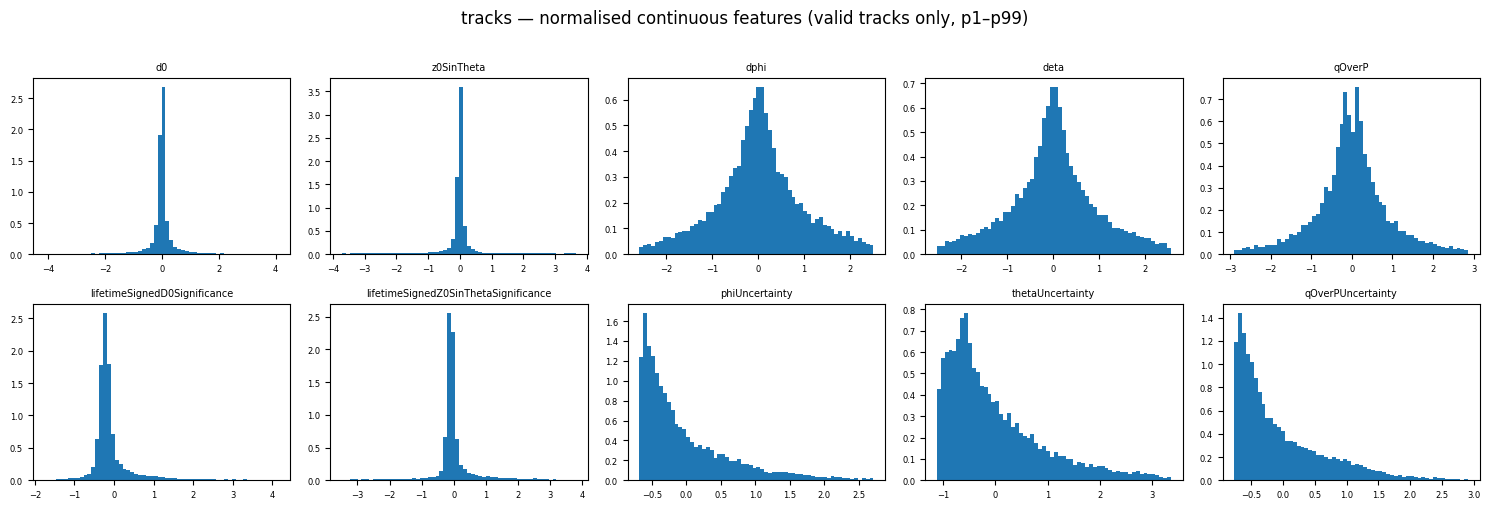

In [14]:
con_feats = list(VARIABLES[CONSTITUENT_OBJECTS[0]].inputs.continuous)
n_feats = len(con_feats)
tensor = torch.cat(con_data[CONSTITUENT_OBJECTS[0]])

ncols = 5
nrows = (n_feats + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.5))
axes = axes.flatten()

for j, name in enumerate(con_feats):
    col = tensor[:, j].numpy()
    # clip outliers for cleaner plot
    lo, hi = np.percentile(col, [1, 99])
    axes[j].hist(col[(col >= lo) & (col <= hi)], bins=60, density=True)
    axes[j].set_title(name, fontsize=7)
    axes[j].tick_params(labelsize=6)

for ax in axes[n_feats:]:
    ax.set_visible(False)

plt.suptitle(
    f'{CONSTITUENT_OBJECTS[0]} — normalised continuous features (valid tracks only, p1–p99)',
    y=1.01,
)
plt.tight_layout()
plt.show()

---
## 7  Valid-track count distribution

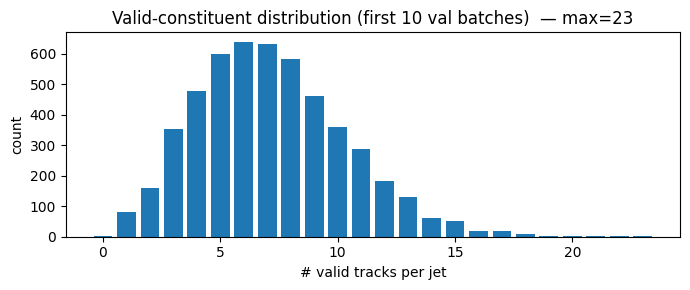

In [15]:
valid_counts = []
for i, b in enumerate(dm.val_dataloader()):
    obj = CONSTITUENT_OBJECTS[0]
    valid_counts.append(b['constituents'][obj]['valid'].sum(dim=1))  # (B,)
    if i >= 9:
        break
valid_counts = torch.cat(valid_counts).numpy()

fig, ax = plt.subplots(figsize=(7, 3))
max_n = valid_counts.max()
ax.hist(valid_counts, bins=range(0, int(max_n) + 2), align='left', rwidth=0.8)
ax.set_xlabel(f'# valid {CONSTITUENT_OBJECTS[0]} per jet')
ax.set_ylabel('count')
ax.set_title(
    f'Valid-constituent distribution (first 10 val batches)  — max={int(max_n)}'
)
plt.tight_layout()
plt.show()

---
## 8  Batch-loading timing
Measures wall-clock time per batch for different `num_workers` values to help pick the optimal setting for this machine.

In [16]:
import time

BATCH_SIZE = 512
N_WARMUP = 3  # batches discarded to fill the prefetch queue before timing
N_TIMED = 20  # batches actually measured
WORKERS_TO_TEST = [0, 1, 2, 4, 8]


def time_loader(num_workers, n_warmup=N_WARMUP, n_timed=N_TIMED):
    """Return (mean_sec, std_sec) of per-batch wall time over n_timed batches."""
    _dm = CatConDataModule(
        train_dataset_path=TRAIN_PATH,
        val_dataset_path=VAL_PATH,
        test_dataset_path=TEST_PATH,
        variables=VARIABLES,
        global_object=GLOBAL_OBJECT,
        constituent_objects=CONSTITUENT_OBJECTS,
        norm_dict_path=NORM_DICT_PATH,
        class_dict_path=CLASS_DICT_PATH,
        batch_size=BATCH_SIZE,
        num_workers=num_workers,
        pin_memory=False,
    )
    _dm.setup('fit')
    it = iter(_dm.train_dataloader())

    for _ in range(n_warmup):  # warm up prefetch queue
        next(it)

    times = []
    for _ in range(n_timed):
        t0 = time.perf_counter()
        next(it)
        times.append(time.perf_counter() - t0)

    return float(np.mean(times)), float(np.std(times))


results = {}
for nw in WORKERS_TO_TEST:
    mean_t, std_t = time_loader(nw)
    results[nw] = (mean_t, std_t)
    print(f'  num_workers={nw:2d}  {mean_t * 1e3:6.1f} ± {std_t * 1e3:.1f} ms/batch')


DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/train/output/pp_output_train.h5
  samples : 18600000

DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/val/output/pp_output_val.h5
  samples : 1860000
  num_workers= 0  9284.3 ± 989.0 ms/batch

DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/train/output/pp_output_train.h5
  samples : 18600000

DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/val/output/pp_output_val.h5
  samples : 1860000
  num_workers= 1  7483.4 ± 680.9 ms/batch

DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/train/output/pp_output_train.h5
  samples : 18600000

DatasetCatCon: /storage3/DSIP/rriva/datasets/transforming-jet-flavor/data_parallel_preprocess_251112_152051/val/out

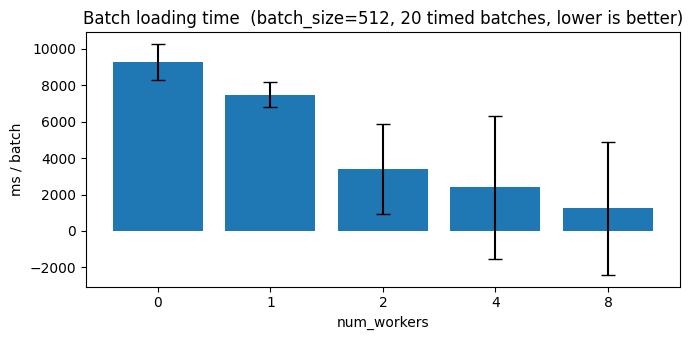

Fastest: num_workers=8  (1235.8 ms/batch)


In [17]:
nw_vals = list(results.keys())
means = [results[nw][0] * 1e3 for nw in nw_vals]
stds = [results[nw][1] * 1e3 for nw in nw_vals]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar([str(nw) for nw in nw_vals], means, yerr=stds, capsize=5)
ax.set_xlabel('num_workers')
ax.set_ylabel('ms / batch')
ax.set_title(
    f'Batch loading time  (batch_size={BATCH_SIZE}, {N_TIMED} timed batches, lower is better)'
)
plt.tight_layout()
plt.show()

best_nw = min(results, key=lambda nw: results[nw][0])
print(f'Fastest: num_workers={best_nw}  ({results[best_nw][0] * 1e3:.1f} ms/batch)')

In [18]:
# Estimated epoch throughput for each worker count
print('── Estimated throughput (train split) ───────')
for nw, (mean_t, _) in results.items():
    samples_per_sec = BATCH_SIZE / mean_t
    epoch_sec = len(dm._train_dataset) / samples_per_sec
    print(
        f'  num_workers={nw:2d}  {samples_per_sec:8,.0f} samples/s  '
        f'→ epoch ≈ {epoch_sec / 60:.1f} min'
    )

── Estimated throughput (train split) ───────
  num_workers= 0        55 samples/s  → epoch ≈ 5621.3 min
  num_workers= 1        68 samples/s  → epoch ≈ 4531.0 min
  num_workers= 2       151 samples/s  → epoch ≈ 2054.9 min
  num_workers= 4       213 samples/s  → epoch ≈ 1458.8 min
  num_workers= 8       414 samples/s  → epoch ≈ 748.2 min
